In [39]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [40]:
df = pd.read_csv("C:\\Coding\\hospital-bed-forecast\\data\\raw\\hospital_indonesia_datasets.csv", sep=';')
df.head()

,id,nama,propinsi,kab,alamat,jenis,kelas,status_blu,kepemilikan,total_tempat_tidur,total_layanan,total_tenaga_kerja
0,1110053,RS Arun Lhokseumawe,Aceh,Kota Lhokseumawe,Jl. Plaju Komplek Perumahan PT Arun Batuphat T...,Rumah Sakit Umum,C,Non BLU/BLUD,SWASTA/LAINNYA,218,36,328
1,1106014,RS Umum Fandika,Aceh,Aceh Tengah,Jl. Terminal Simpang Wariji Blangkolak 1 Kec. ...,Rumah Sakit Umum,D,Non BLU/BLUD,SWASTA/LAINNYA,45,15,45
2,1171110,RS Umum Daerah Meuraxa,Aceh,Kota Banda Aceh,Jl. Soekarno Hatta Km. 2 Desa Mibo Kecamatan B...,Rumah Sakit Umum,B,BLUD,Pemkot,310,77,487
3,1171163,RS Gigi Mulut Universitas Syiah Kuala,Aceh,Kota Banda Aceh,Jl. Prof A. Madjid Ibrahim I No. 5 Banda Aceh ...,Rumah Sakit Khusus Gigi dan Mulut,B,BLU,Kementerian Lain,11,24,0
4,1102027,RS Umum Daerah Kota Subulussalam,Aceh,Kota Subulussalam,Jl. Hamzah Fansyuri (Subulussalam-Rundeng) K...,Rumah Sakit Umum,C,BLUD,Pemkot,189,34,537


In [70]:
print(f"Shape: {df.shape} || Description:  {df.describe()}")
print(f"Duplicated : {df.duplicated().sum()}")

Shape: (3155, 12) || Description:                   id  total_tempat_tidur  total_layanan  total_tenaga_kerja
count  3.155000e+03         3155.000000    3155.000000         3155.000000
mean   3.803327e+06          135.433914      41.097306          261.980666
std    2.005303e+06          550.960235      30.583893          382.352731
min    1.101015e+06            0.000000       1.000000            0.000000
25%    3.171859e+06           54.000000      22.000000           56.500000
50%    3.325039e+06          102.000000      31.000000          153.000000
75%    5.103046e+06          155.000000      50.000000          335.000000
max    9.271080e+06        30343.000000     419.000000         7939.000000
Duplicated : 0


In [71]:
for col in df.columns:
    print(f"Col Name: {col} || Datatype: {df[col].dtype} || Is null %: {df[col].isnull().mean()}")

Col Name: id || Datatype: int64 || Is null %: 0.0
Col Name: nama || Datatype: str || Is null %: 0.0
Col Name: propinsi || Datatype: str || Is null %: 0.0
Col Name: kab || Datatype: str || Is null %: 0.0
Col Name: alamat || Datatype: str || Is null %: 0.0
Col Name: jenis || Datatype: str || Is null %: 0.0
Col Name: kelas || Datatype: str || Is null %: 0.0
Col Name: status_blu || Datatype: str || Is null %: 0.0
Col Name: kepemilikan || Datatype: str || Is null %: 0.0
Col Name: total_tempat_tidur || Datatype: int64 || Is null %: 0.0
Col Name: total_layanan || Datatype: int64 || Is null %: 0.0
Col Name: total_tenaga_kerja || Datatype: int64 || Is null %: 0.0


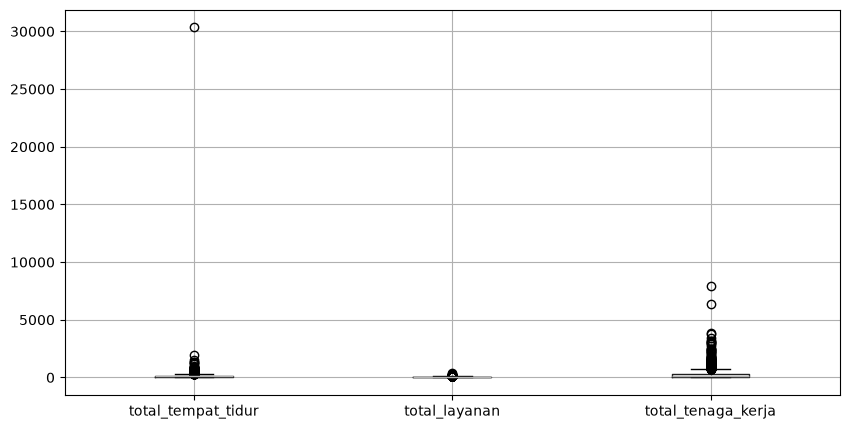

Number of outliers: 151
Number of outliers: 266
Number of outliers: 205


In [76]:
columns_IQR = ['total_tempat_tidur', 'total_layanan', 'total_tenaga_kerja']
df[columns_IQR ].boxplot(figsize=(10, 5))
plt.show()

for col_name in columns_IQR:
    Q1 = df[col_name].quantile(0.25)
    Q3 = df[col_name].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[(df[col_name] < lower_bound) | (df[col_name] > upper_bound)]
    print(f"Number of outliers: {len(outliers)}")

C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24272\4293375549.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')
C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24272\4293375549.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')
C:\Users\USER-PC\AppData\Local\Temp\ipykernel_24272\4293375549.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')


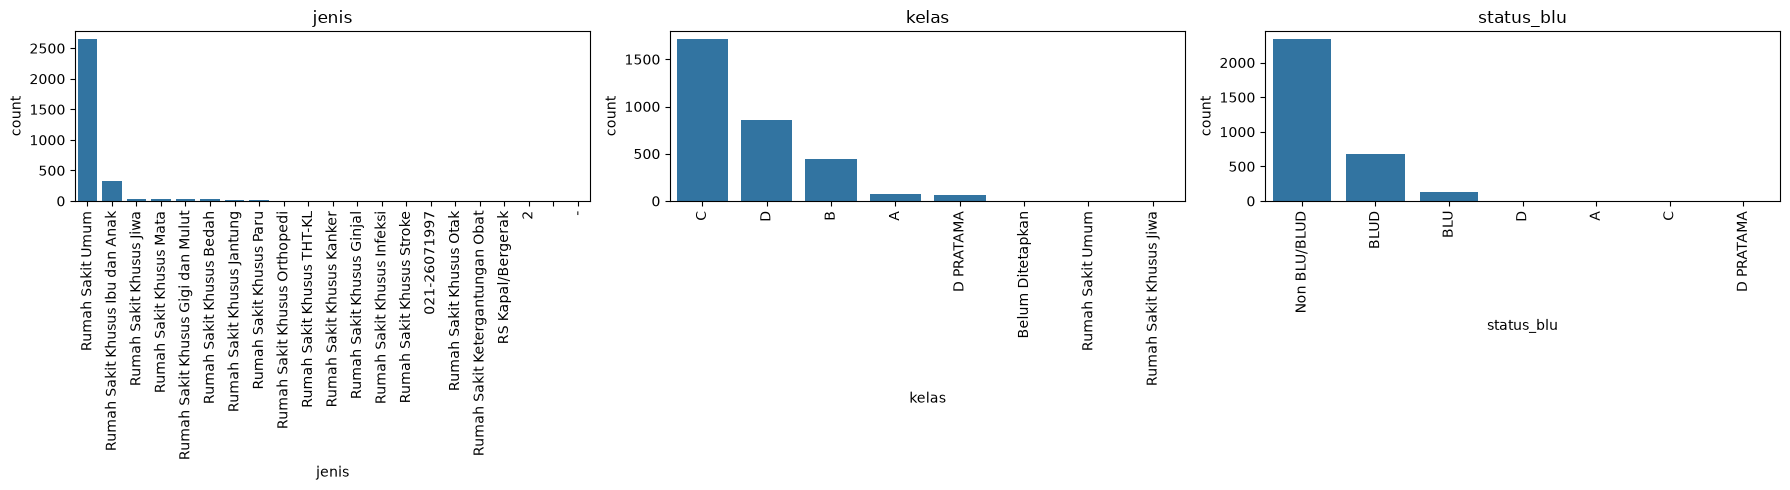

In [77]:
cat_cols = ['jenis', 'kelas', 'status_blu']  # manually specify instead of select_dtypes

fig, axes = plt.subplots(1, len(cat_cols), figsize=(6 * len(cat_cols), 5))

for i, col in enumerate(cat_cols):
    sns.countplot(x=df[col], ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(col)
    axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=90, ha='center')

plt.tight_layout()
plt.show()

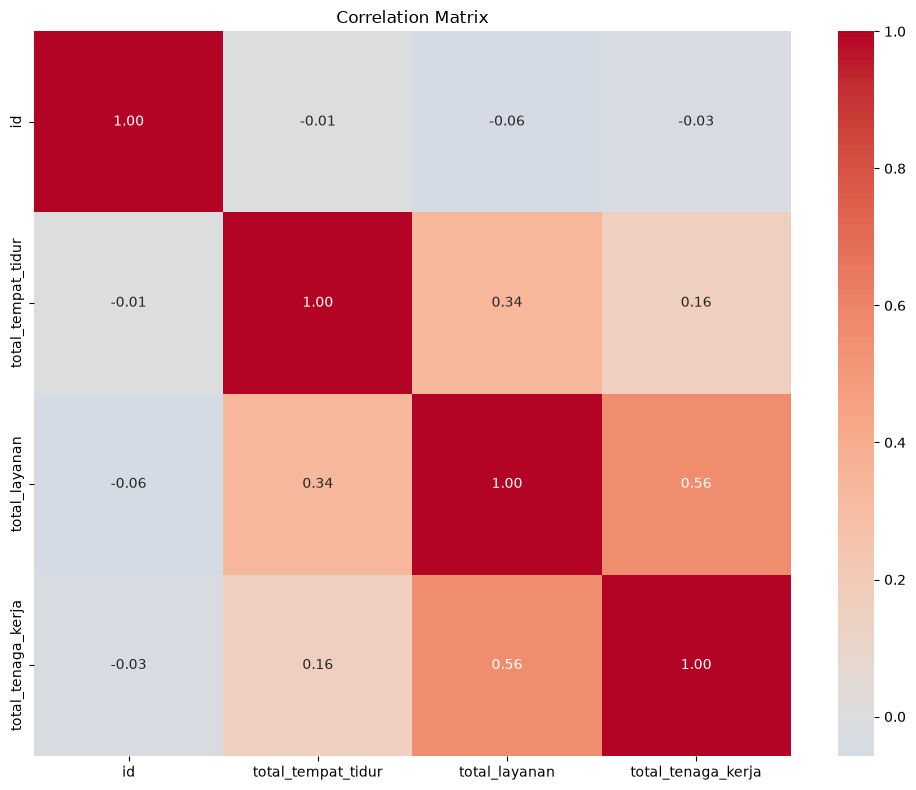

In [78]:
corr_matrix = df.select_dtypes(include='number').corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.show()